In [1]:
## Importation of all the needed modules

import numpy as np
import pandas as pd
import seaborn as sns

Feedback from assignment

1. Title my visualizations
2. Positioning the boxplot horizontally
3. Use markdown to provide more comprehensive explanations compared to comments
4. Limiting the number of dps for floating point outputs 

In [2]:
df = pd.read_csv("electric_vehicles_spec_2025.csv")

In [4]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
df

,brand,model,top_speed_kmh,battery_capacity_kWh,battery_type,number_of_cells,torque_nm,efficiency_wh_per_km,range_km,acceleration_0_100_s,fast_charging_power_kw_dc,fast_charge_port,towing_capacity_kg,cargo_volume_l,seats,drivetrain,segment,length_mm,width_mm,height_mm,car_body_type,source_url
0,Abarth,500e Convertible,155,37.8,Lithium-ion,192.0,235.0,156,225,7.0,67.0,CCS,0.0,185,4,FWD,B - Compact,3673,1683,1518,Hatchback,https://ev-database.org/car/1904/Abarth-500e-C...
1,Abarth,500e Hatchback,155,37.8,Lithium-ion,192.0,235.0,149,225,7.0,67.0,CCS,0.0,185,4,FWD,B - Compact,3673,1683,1518,Hatchback,https://ev-database.org/car/1903/Abarth-500e-H...
2,Abarth,600e Scorpionissima,200,50.8,Lithium-ion,102.0,345.0,158,280,5.9,79.0,CCS,0.0,360,5,FWD,JB - Compact,4187,1779,1557,SUV,https://ev-database.org/car/3057/Abarth-600e-S...
3,Abarth,600e Turismo,200,50.8,Lithium-ion,102.0,345.0,158,280,6.2,79.0,CCS,0.0,360,5,FWD,JB - Compact,4187,1779,1557,SUV,https://ev-database.org/car/3056/Abarth-600e-T...
4,Aiways,U5,150,60.0,Lithium-ion,NaN,310.0,156,315,7.5,78.0,CCS,NaN,496,5,FWD,JC - Medium,4680,1865,1700,SUV,https://ev-database.org/car/1678/Aiways-U5
5,Aiways,U6,160,60.0,Lithium-ion,NaN,315.0,150,350,7.0,78.0,CCS,NaN,472,5,FWD,JC - Medium,4805,1880,1641,SUV,https://ev-database.org/car/1766/Aiways-U6
6,Alfa,Romeo Junior Elettrica 54 kWh,150,50.8,Lithium-ion,102.0,260.0,128,320,9.0,85.0,CCS,0.0,400,5,FWD,JB - Compact,4173,1781,1532,SUV,https://ev-database.org/car/2184/Alfa-Romeo-Ju...
7,Alfa,Romeo Junior Elettrica 54 kWh Veloce,200,50.8,Lithium-ion,102.0,345.0,164,310,6.0,85.0,CCS,0.0,400,5,FWD,JB - Compact,4173,1781,1505,SUV,https://ev-database.org/car/2185/Alfa-Romeo-Ju...
8,Alpine,A290 Electric 180 hp,160,52.0,Lithium-ion,184.0,285.0,138,310,7.4,70.0,CCS,500.0,326,5,FWD,B - Compact,3997,1823,1512,Hatchback,https://ev-database.org/car/2268/Alpine-A290-E...
9,Alpine,A290 Electric 220 hp,170,52.0,Lithium-ion,184.0,300.0,144,305,6.4,70.0,CCS,500.0,326,5,FWD,B - Compact,3997,1823,1512,Hatchback,https://ev-database.org/car/2269/Alpine-A290-E...


## Data cleaning

### Dirt #1 - Missing values


In [4]:
df.isna().sum()

brand                          0
model                          1
top_speed_kmh                  0
battery_capacity_kWh           0
battery_type                   0
number_of_cells              202
torque_nm                      7
efficiency_wh_per_km           0
range_km                       0
acceleration_0_100_s           0
fast_charging_power_kw_dc      1
fast_charge_port               1
towing_capacity_kg            26
cargo_volume_l                 1
seats                          0
drivetrain                     0
segment                        0
length_mm                      0
width_mm                       0
height_mm                      0
car_body_type                  0
source_url                     0
dtype: int64

In [5]:
df['source_url']

0      https://ev-database.org/car/1904/Abarth-500e-C...
1      https://ev-database.org/car/1903/Abarth-500e-H...
2      https://ev-database.org/car/3057/Abarth-600e-S...
3      https://ev-database.org/car/3056/Abarth-600e-T...
4             https://ev-database.org/car/1678/Aiways-U5
5             https://ev-database.org/car/1766/Aiways-U6
6      https://ev-database.org/car/2184/Alfa-Romeo-Ju...
7      https://ev-database.org/car/2185/Alfa-Romeo-Ju...
8      https://ev-database.org/car/2268/Alpine-A290-E...
9      https://ev-database.org/car/2269/Alpine-A290-E...
10     https://ev-database.org/car/3055/Audi-A6-Avant...
11     https://ev-database.org/car/2272/Audi-A6-Avant...
12     https://ev-database.org/car/3054/Audi-A6-Avant...
13     https://ev-database.org/car/3053/Audi-A6-Sport...
14     https://ev-database.org/car/2270/Audi-A6-Sport...
15     https://ev-database.org/car/3052/Audi-A6-Sport...
16     https://ev-database.org/car/3149/Audi-Q4-Sport...
17     https://ev-database.org/

In [6]:
# Check the cols within each row to see if that row has a missing value
# It returns a Series
missing_rows = df.isnull().any(axis=1)

# Boolean indexing to print out such rows
df[missing_rows]

,brand,model,top_speed_kmh,battery_capacity_kWh,battery_type,number_of_cells,torque_nm,efficiency_wh_per_km,range_km,acceleration_0_100_s,fast_charging_power_kw_dc,fast_charge_port,towing_capacity_kg,cargo_volume_l,seats,drivetrain,segment,length_mm,width_mm,height_mm,car_body_type,source_url
4,Aiways,U5,150,60.0,Lithium-ion,NaN,310.0,156,315,7.5,78.0,CCS,NaN,496,5,FWD,JC - Medium,4680,1865,1700,SUV,https://ev-database.org/car/1678/Aiways-U5
5,Aiways,U6,160,60.0,Lithium-ion,NaN,315.0,150,350,7.0,78.0,CCS,NaN,472,5,FWD,JC - Medium,4805,1880,1641,SUV,https://ev-database.org/car/1766/Aiways-U6
38,BMW,i4 M50,225,81.3,Lithium-ion,NaN,795.0,197,450,3.9,131.0,CCS,1600.0,470,5,AWD,D - Large,4783,1852,1448,Liftback Sedan,https://ev-database.org/car/2201/BMW-i4-M50
39,BMW,i4 eDrive35,190,67.1,Lithium-ion,NaN,400.0,174,430,6.0,95.0,CCS,1600.0,470,5,RWD,D - Large,4783,1852,1448,Liftback Sedan,https://ev-database.org/car/2198/BMW-i4-eDrive35
40,BMW,i4 eDrive40,190,81.3,Lithium-ion,NaN,430.0,174,515,5.6,131.0,CCS,1600.0,470,5,RWD,D - Large,4783,1852,1448,Liftback Sedan,https://ev-database.org/car/2199/BMW-i4-eDrive40
41,BMW,i4 xDrive40,200,81.3,Lithium-ion,NaN,600.0,183,490,5.1,131.0,CCS,1600.0,470,5,AWD,D - Large,4783,1852,1448,Liftback Sedan,https://ev-database.org/car/2200/BMW-i4-xDrive40
42,BMW,i5 M60 xDrive Sedan (MY25),230,81.2,Lithium-ion,NaN,795.0,172,430,3.8,136.0,CCS,2000.0,490,5,AWD,E - Executive,5060,1900,1505,Sedan,https://ev-database.org/car/3114/BMW-i5-M60-xD...
43,BMW,i5 M60 xDrive Touring (MY25),230,81.2,Lithium-ion,NaN,795.0,179,425,3.9,136.0,CCS,2000.0,570,5,AWD,E - Executive,5060,1900,1505,Station/Estate,https://ev-database.org/car/3117/BMW-i5-M60-xD...
44,BMW,i5 eDrive40 Sedan (MY25),193,81.2,Lithium-ion,NaN,400.0,159,480,6.0,136.0,CCS,1500.0,490,5,RWD,E - Executive,5060,1900,1515,Sedan,https://ev-database.org/car/3112/BMW-i5-eDrive...
45,BMW,i5 eDrive40 Touring (MY25),193,81.2,Lithium-ion,NaN,400.0,165,465,6.1,136.0,CCS,1500.0,570,5,RWD,E - Executive,5060,1900,1515,Station/Estate,https://ev-database.org/car/3115/BMW-i5-eDrive...


In [5]:
## For torque, -- 7
# There are no records of their biodata on the electric vehicle records
# Thus, droping is the best option
df.dropna(subset='torque_nm',inplace=True)

In [ ]:
## For towing capacity, -- 26

In [7]:
### For num. of cells, -- 202
## By going through the data source, the actual values can't be obtained

In [8]:
### For model, -- 1
## By going through the data source, the actual value can be obtained and is thus replaced
df.loc[477,'model'] = 'firefly'

In [9]:
### For fast charging power, -- 1
# Different options are available to different countries, thus we settle for the more common actual value
df.loc[356,'fast_charging_power_kw_dc'] = 2.3
df.loc[356,'fast_charge_port'] = 'Wall Plug'

In [10]:
### For cargo volume, -- 1
## 1. No data is available on it 
## 2. We can't replace with mean, median or mode
## 3. Best option is to drop
df.drop(index=128, axis=1, inplace=True)

## Computing statistics -- Mean, Mode and Std

### Top speeds

In [11]:
ts_mean = df['top_speed_kmh'].mean()
ts_mode = df['top_speed_kmh'].max()
ts_std = df['top_speed_kmh'].std()

print(f'Mean: {ts_mean} \nMode: {ts_mode} \nStandard Deviation: {ts_std}')

Mean: 185.57232704402514 
Mode: 325 
Standard Deviation: 34.238374544102214


### Battery capacity

In [12]:
bc_mean = df['battery_capacity_kWh'].mean()
bc_mode = df['battery_capacity_kWh'].max()
bc_std = df['battery_capacity_kWh'].std()

print(f'Mean: {bc_mean} \nMode: {bc_mode} \nStandard Deviation: {bc_std}')

Mean: 74.10754716981133 
Mode: 118.0 
Standard Deviation: 20.30441091448924


### Number of cells

In [13]:
noc_mean = df['number_of_cells'].mean()
noc_mode = df['number_of_cells'].max()
noc_std = df['number_of_cells'].std()

print(f'Mean: {noc_mean} \nMode: {noc_mode} \nStandard Deviation: {noc_std}')

Mean: 485.29347826086956 
Mode: 7920.0 
Standard Deviation: 1210.8197331909425


### Torque

In [14]:
t_mean = df['torque_nm'].mean()
t_mode = df['torque_nm'].max()
t_std = df['torque_nm'].std()

print(f'Mean: {t_mean} \nMode: {t_mode} \nStandard Deviation: {t_std}')

Mean: 498.45531914893616 
Mode: 1350.0 
Standard Deviation: 241.52709154969864


### Range

In [15]:
r_mean = df['range_km'].mean()
r_mode = df['range_km'].max()
r_std = df['range_km'].std()

print(f'Mean: {r_mean} \nMode: {r_mode} \nStandard Deviation: {r_std}')

Mean: 393.58490566037733 
Mode: 685 
Standard Deviation: 103.01515156691534


## Data visualization

<Axes: xlabel='top_speed_kmh', ylabel='Count'>

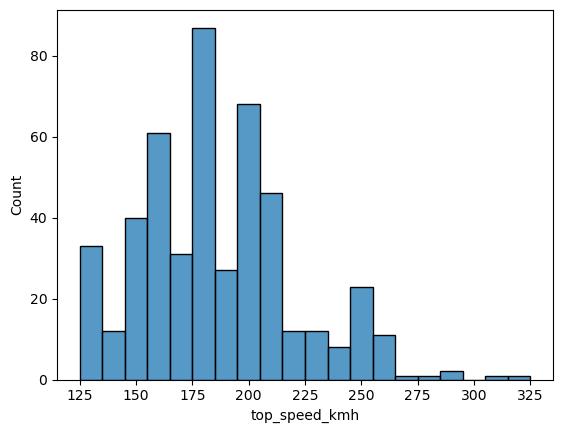

In [16]:
## Histogram from Top speed
sns.histplot(df['top_speed_kmh'])

<Axes: xlabel='battery_capacity_kWh', ylabel='Count'>

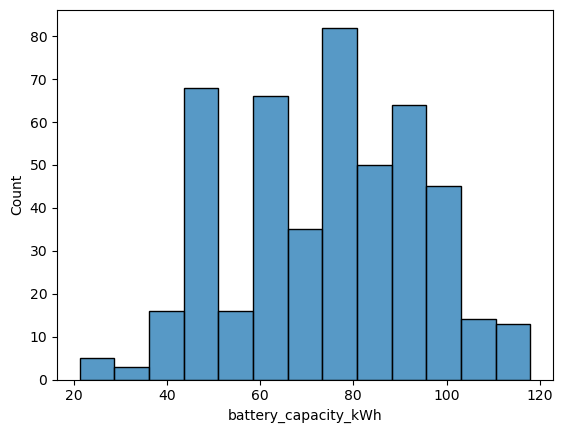

In [17]:
## Histogram for battery capacity
sns.histplot(df['battery_capacity_kWh'])

<Axes: ylabel='number_of_cells'>

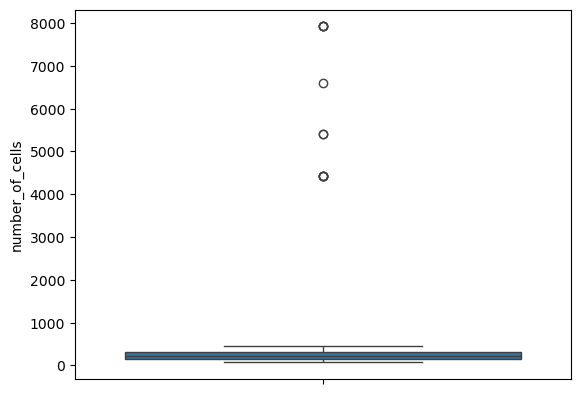

In [18]:
sns.boxplot(df['number_of_cells'])

<Axes: ylabel='torque_nm'>

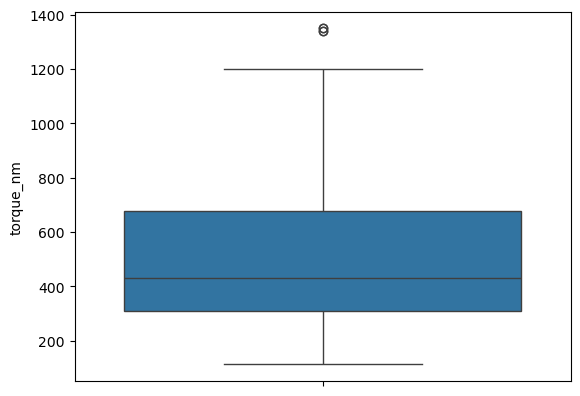

In [19]:
sns.boxplot(df['torque_nm'])

<Axes: ylabel='range_km'>

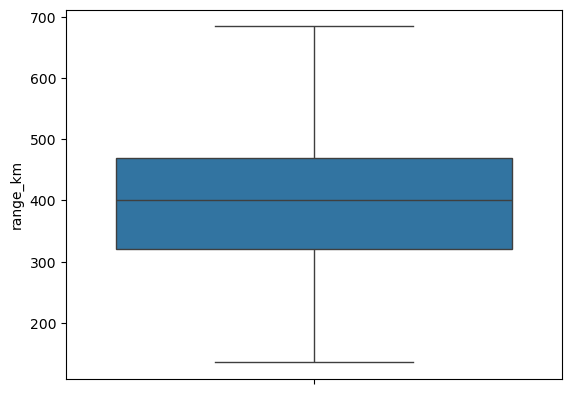

In [20]:
sns.boxplot(df['range_km'])